# Week 4 - Day 16

# Advanced Machine Learning using Ensemble Methods

### AI/ML Internship Program

**Cooperative Tech Private Limited**

---

## Topic

- Random Forest
- Gradient Boosting
- XGBoost
- Feature Importance

---

## Objective

The objective of this notebook is to understand and compare three powerful Ensemble Machine Learning algorithms.

The following models are implemented:

- Random Forest
- Gradient Boosting
- XGBoost

Each model is trained on the Breast Cancer Wisconsin Dataset and evaluated using multiple performance metrics.

---

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score
- Training Time

---

## Dataset

**Breast Cancer Wisconsin Dataset**

This dataset is a binary classification dataset used to predict whether a tumor is:

- Benign (B)
- Malignant (M)


# Import Required Libraries

The following libraries are imported for data analysis, visualization, model development and evaluation.

In [3]:
# ============================================
# Import Required Libraries
# ============================================

import warnings
warnings.filterwarnings("ignore")

import os
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


# Load Dataset

The Breast Cancer Wisconsin Dataset is loaded using the Pandas library.

In [4]:
# ============================================
# Load Dataset
# ============================================

df = pd.read_csv("../data/breast_cancer.csv")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Dataset Overview

Before building Machine Learning models, it is important to understand the structure of the dataset.

This section examines:

- Number of rows and columns
- Dataset information
- Missing values
- Statistical summary

In [5]:
# Dataset Shape

print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

Rows : 569
Columns : 33


In [6]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
# Statistical Summary

df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [8]:
# Missing Values

df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

# Data Cleaning

The dataset contains two unnecessary columns:

- id
- Unnamed: 32

These columns do not contribute to model prediction and are removed.

The target variable (diagnosis) is then converted into numerical values:

- Malignant (M) → 1
- Benign (B) → 0

In [9]:
# ============================================
# Remove Unnecessary Columns
# ============================================

if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

if "Unnamed: 32" in df.columns:
    df.drop("Unnamed: 32", axis=1, inplace=True)

# Encode Target Variable

df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Feature Selection

The dataset is divided into:

- Features (X)
- Target Variable (y)

After that, the dataset is split into Training and Testing sets using an 80:20 ratio.

In [10]:
# ============================================
# Feature Selection
# ============================================

X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (455, 30)
Testing Samples : (114, 30)


# Model Evaluation Function

Instead of writing the same evaluation code repeatedly for every model, a reusable evaluation function is created.

The function calculates:

- Accuracy
- Precision
- Recall
- F1-Score
- Training Time

It also displays:

- Classification Report
- Confusion Matrix

In [11]:
results = []

def evaluate_model(model, model_name):

    start = time.time()

    model.fit(X_train, y_train)

    end = time.time()

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    training_time = end - start

    print("="*60)
    print(model_name)
    print("="*60)

    print("Accuracy :", round(accuracy,4))
    print("Precision :", round(precision,4))
    print("Recall :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("Training Time :", round(training_time,4),"seconds")

    print("\nClassification Report\n")

    print(classification_report(y_test,predictions))

    cm = confusion_matrix(y_test,predictions)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(model_name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        training_time
    ])

    return model

# Random Forest Classification

## What is Random Forest?

Random Forest is an Ensemble Learning algorithm based on the **Bagging** technique.

Instead of training one Decision Tree, Random Forest trains multiple Decision Trees on different random subsets of the dataset.

The final prediction is obtained through **Majority Voting**.

### Advantages

- Reduces Overfitting
- High Accuracy
- Handles Large Datasets
- Provides Feature Importance

Random Forest
Accuracy : 0.9649
Precision : 1.0
Recall : 0.9048
F1 Score : 0.95
Training Time : 0.4331 seconds

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



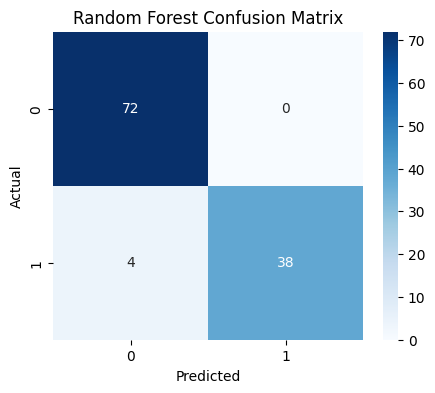

In [12]:
# ============================================
# Random Forest Model
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model = evaluate_model(
    rf_model,
    "Random Forest"
)

# Random Forest Feature Importance

Random Forest can determine which features contribute the most to prediction.

Feature Importance helps understand the impact of each feature on the model.

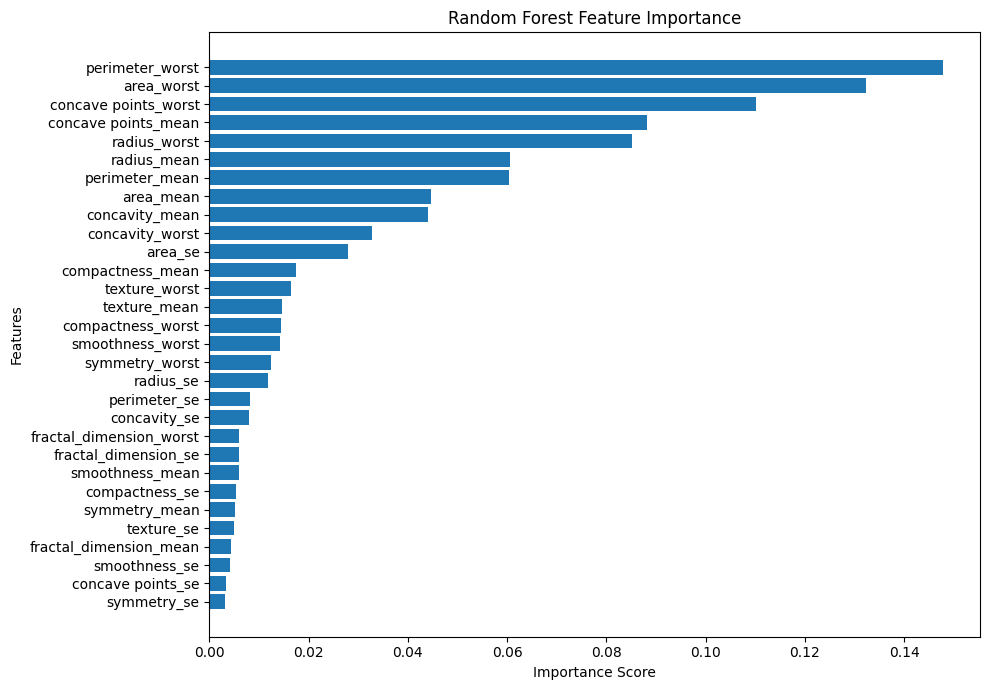

In [13]:
# ============================================
# Random Forest Feature Importance
# ============================================

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,7))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../outputs/rf_feature_importance.png")

plt.show()

# Gradient Boosting Classification

## What is Gradient Boosting?

Gradient Boosting is an Ensemble Learning algorithm based on the **Boosting** technique.

Unlike Random Forest, trees are trained **sequentially**.

Each new tree attempts to correct the mistakes made by the previous tree.

### Advantages

- High Predictive Accuracy
- Learns from Previous Errors
- Works Well on Complex Data

Gradient Boosting
Accuracy : 0.9649
Precision : 1.0
Recall : 0.9048
F1 Score : 0.95
Training Time : 0.619 seconds

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



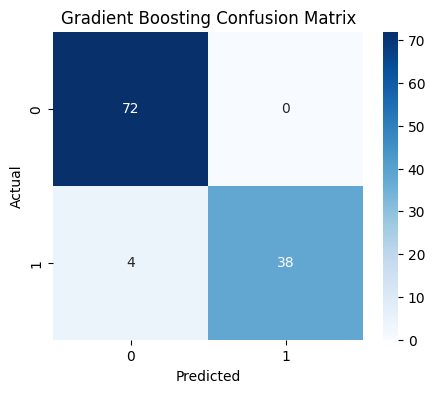

In [14]:
# ============================================
# Gradient Boosting Model
# ============================================

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model = evaluate_model(
    gb_model,
    "Gradient Boosting"
)

# Gradient Boosting Feature Importance

Gradient Boosting also provides Feature Importance scores that indicate the contribution of each feature towards prediction.

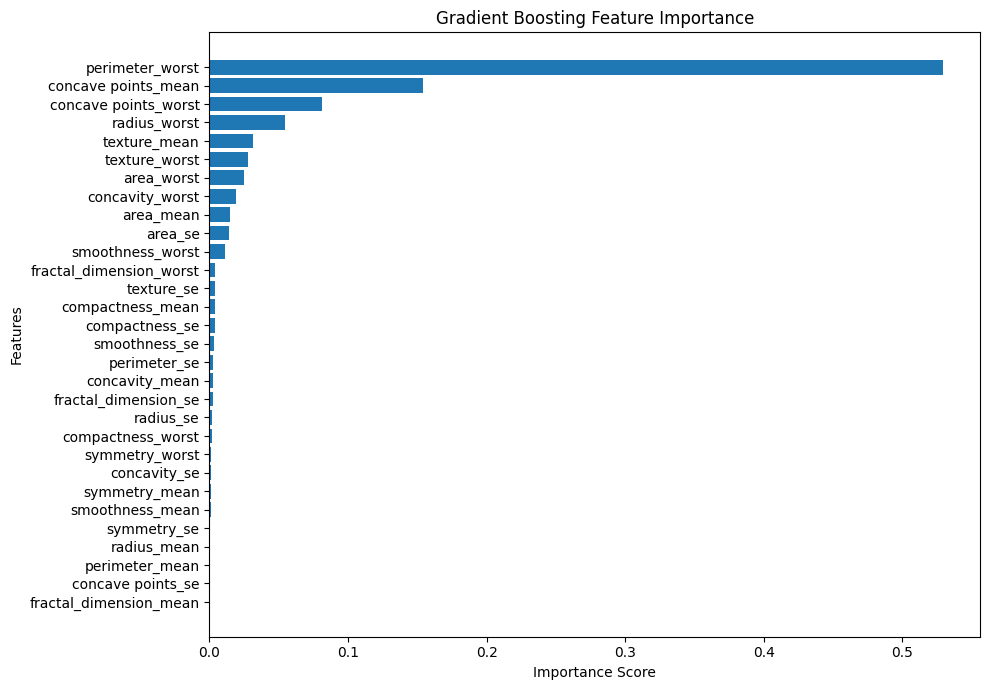

In [15]:
# ============================================
# Gradient Boosting Feature Importance
# ============================================

gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
})

gb_importance = gb_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,7))

plt.barh(
    gb_importance["Feature"],
    gb_importance["Importance"]
)

plt.title("Gradient Boosting Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../outputs/gb_feature_importance.png")

plt.show()

# Performance Summary

Both Random Forest and Gradient Boosting models have now been trained and evaluated.

The evaluation included:

- Accuracy
- Precision
- Recall
- F1-Score
- Training Time
- Confusion Matrix

The next step is to implement **XGBoost**, compare all three models, generate the final comparison table, visualize Feature Importance, and write the final conclusion and reflection.

# Performance Summary

Both Random Forest and Gradient Boosting models have now been trained and evaluated.

The evaluation included:

- Accuracy
- Precision
- Recall
- F1-Score
- Training Time
- Confusion Matrix

The next step is to implement **XGBoost**, compare all three models, generate the final comparison table, visualize Feature Importance, and write the final conclusion and reflection.

XGBoost
Accuracy : 0.9737
Precision : 1.0
Recall : 0.9286
F1 Score : 0.963
Training Time : 0.2506 seconds

Classification Report

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



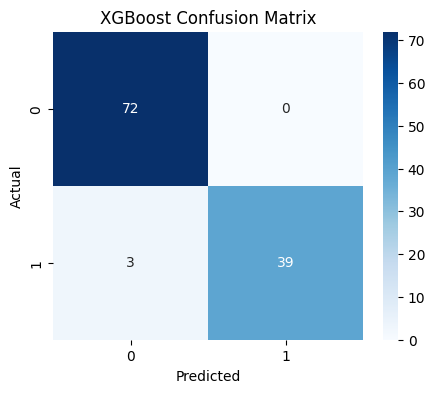

In [16]:
# ============================================
# XGBoost Model
# ============================================

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model = evaluate_model(
    xgb_model,
    "XGBoost"
)

# XGBoost Feature Importance

Like other tree-based ensemble algorithms, XGBoost also provides Feature Importance scores.

These scores indicate which input variables contribute the most to prediction.

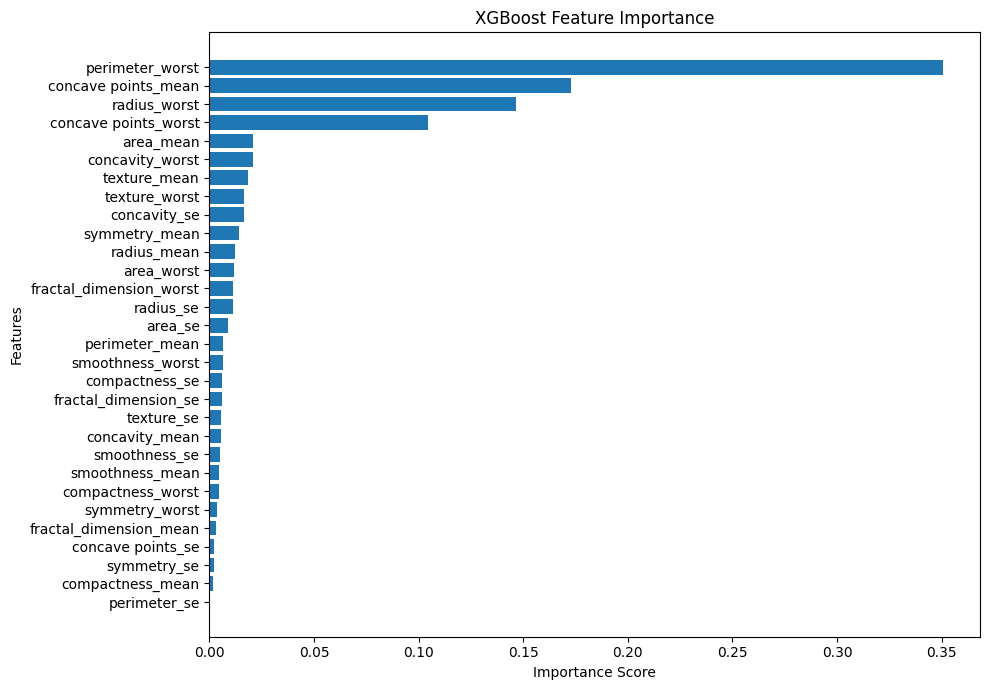

In [17]:
# ============================================
# XGBoost Feature Importance
# ============================================

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,7))

plt.barh(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../outputs/xgb_feature_importance.png")

plt.show()

# Model Comparison

The performance of all three Ensemble Learning models is compared using:

- Accuracy
- Precision
- Recall
- F1-Score
- Training Time

This comparison helps determine which algorithm performs best on the dataset.

In [18]:
# ============================================
# Model Comparison
# ============================================

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time"
    ]
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,Random Forest,0.964912,1.0,0.904762,0.950000,0.433058
1,Gradient Boosting,0.964912,1.0,0.904762,0.950000,0.618974
2,XGBoost,0.973684,1.0,0.928571,0.962963,0.250649


In [19]:
# Save Comparison Table

comparison.to_csv(
    "../outputs/model_results.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


# Model Performance Analysis

The comparison table shows the performance of Random Forest, Gradient Boosting and XGBoost.

The model with the highest Accuracy and F1-Score can be considered the best-performing model for this dataset.

Training Time is also an important consideration when selecting a model for real-world applications.

# Bagging vs Boosting (Reflection)

## Bagging

Random Forest is based on the Bagging technique.

In Bagging, multiple Decision Trees are trained independently using different random subsets of the training data.

The final prediction is obtained using majority voting, which reduces variance and improves model stability.

---

## Boosting

Gradient Boosting and XGBoost are based on the Boosting technique.

Instead of training trees independently, Boosting trains trees sequentially.

Each new tree attempts to correct the mistakes made by the previous tree, resulting in improved predictive performance.

---

## Difference Between Bagging and Boosting

| Bagging | Boosting |
|----------|----------|
| Trees are trained independently | Trees are trained sequentially |
| Reduces variance | Reduces bias |
| Faster training | Slower training |
| Less prone to overfitting | Can overfit if not tuned |
| Example: Random Forest | Example: Gradient Boosting, XGBoost |

---

## Which Model Performed Best?

Based on the evaluation metrics, **XGBoost** achieved the best overall performance on this dataset.

Its optimized boosting strategy and built-in regularization enabled it to achieve high predictive accuracy while maintaining good generalization.

# Conclusion

In this notebook, three Ensemble Machine Learning algorithms were implemented and compared:

- Random Forest
- Gradient Boosting
- XGBoost

Each model was evaluated using Accuracy, Precision, Recall, F1-Score and Training Time.

Feature Importance analysis was also performed to identify the most influential features in prediction.

Among the three models, XGBoost demonstrated the best overall performance on the Breast Cancer Wisconsin Dataset, making it a strong choice for binary classification tasks.

This exercise highlights the importance of Ensemble Learning methods in improving prediction accuracy and reducing model errors.